# Machine Learning Regression (family = 'reg_ml')

In this module, we assume that the conditional outcome model in each source domain $1 \le l \le L$ admits any form:

$$
Y^{(l)} = f^{(l)}(X^{(l)}) + \varepsilon^{(l)}, 
\qquad \text{with} \quad \mathbb{E}[\varepsilon^{(l)}|X^{(l)}] = 0,
$$

which implies
$$
\mathbb{E}[Y^{(l)}|X^{(l)}] = f^{(l)}(X^{(l)}) X^{(l)}.
$$

To learn a **robust prediction model** under domain shifts, the CGDRO framework solves the following minimax optimization problem:

$$
f^* = \arg\min_{f \in \mathcal{F}}
\max_{\mathbf{T} \in \mathcal{C}}
\mathbb{E}_{(X, Y) \sim \mathbf{T}} \ell(X, Y; f),

$$

where $\mathcal{C}$ is the **uncertainty class** over possible target distributions, as defined in the [Introduction](../setup/intro.md).

We can use `cgdro_()` with `family = 'reg_ml'` for machine learning regressions.

Now we give an example showing how to implement `family = 'reg_ml'` with three different loss functions:

- Reward-based loss  
- Squared loss  
- Regret-based loss  

---

## Example

### Data Generating Process

In this example, we generate a non-linear multi-source domain data with $3$ domains, putting $10,000$ samples on each source domain and $100,000$ samples on the target domain. The dimension of the parameters is $p=5$,

In [ ]:
# number of source groups = 3, each with 1000 samples, and 10000 target samples
# dimension p = 5
data <- simu_reg_ml(n_vec = c(10000,10000,10000), n0=100000, N_label = 20, p=5, seed = 123)
Xlist = data$X_list
Ylist = data$Y_list
X0 = data$X0
Y0 = data$Y0
X0_label = data$X0_label
Y0_label = data$Y0_label

### Implementation & Prediction

We implement three loss functions by `Regression.ml`, including `reward`, `squaredloss`, and `regret`. Geometrically, `reward`: $f^∗$ is the point closest to the original within the convex hull of ${f(l)}_{l\in[L]}$; `squaredloss`: $f^{sq}$ corresponds to the source model with the largest noise level with the highest noise level when this noise is substantially higher than that in other sources; `regret`: $f^{reg}$ is the center of the smallest circle enclosing all individual source models.


![Loss Types](../assets/loss_type.png)

#### loss_type =  reward

We define the loss as  
$\ell(X,Y;f) = (Y -  f(X))^2 - Y^2$.

Under this choice, the minimax problem becomes

$$
\begin{aligned}
f^*
&= \arg\min_{f \in \mathcal{F}} \max_{\mathbf{T}\in \mathcal{C}}
\mathbb{E}_{\mathbf{T}}\!\left[(Y-f(X))^2 - Y^2\right] \\[2mm]
&= \arg\max_{f \in \mathcal{F}} \min_{\mathbf{T}\in \mathcal{C}}
\mathbb{E}_{\mathbf{T}}\!\left[Y^2 - (Y-f(X))^2\right].
\end{aligned}
$$

The right-hand side shows that  $\mathbb{E}_{\mathbf{T}}\!\left[Y^2 - (Y - f(X))^2\right]$  can be interpreted as the **explained variance** of $Y$ by the predictor $f(X)$ (assuming $Y$ is centered).  
Hence, the CGDRO model maximizes the **worst-case explained variance** across all possible target distributions in $\mathcal{C}$.


**Proposition**

The CGDRO model $f^*$ with reward-based loss admits the closed form:

$$
f^* = \sum_{l=1}^L q_l^* \, f^{(l)},
\qquad
q^* = \arg\min_{q \in \Delta^L} q^\top \Gamma q,
$$

where $\Gamma \in \mathbb{R}^{L \times L}$ is defined by  

$$
\Gamma_{k,l} =  \mathbb{E}_{\mathbf{Q}}[f^{(k)}(X) f^{(l)}(X)], 
\quad k,l \in [L].
$$

This result implies that $f^*$ is a **convex combination** of the source-specific conditional models $\{f^{(l)}\}$,  
with weights $q^*$ minimizing the second-moment matrix of the target covariates.

In [ ]:
fit <- cgdro_(Xlist, Ylist, X0, loss_type = "reward",
             family = "reg_ml", f_learner = "xgb", w_learner = "linear",
             bias_correct = TRUE,
             priors = NULL,
             ridge = 1e-8,
             seed = 123)

In [ ]:
fit$weight_

[1] 0.3174991 0.5495492 0.1329517

In [ ]:
pred <- predict_cgdro_(fit)  # N x 1 vector of predicted values
head(pred)

[1] -0.4595518 -0.7397297 -1.6012894 34.3347049  1.6208214 -4.6920144

#### loss_type =  squaredloss

We may also choose the standard squared loss
$\ell(X,Y;f) = (Y - f(X))^2$.

Then the minimax problem becomes

$$
f_{\text{sq}} =
\arg\min_{f} \max_{\mathbf{T} \in \mathcal{C}}
\mathbb{E}_{(X,Y)\sim \mathbf{T}} (Y - f(X))^2.
$$

Define the noise level in each source domain:

$$
(\sigma^{(l)})^2 = \mathbb{E}\!\left[(\varepsilon_i^{(l)})^2 \mid X_i^{(l)}\right],
\qquad
\varepsilon_i^{(l)} = Y_i^{(l)} - f^{(l)}(X_i^{(l)}).
$$

Let $\boldsymbol{\sigma}^2 = ((\sigma^{(1)})^2, \ldots, (\sigma^{(L)})^2)$.

**Proposition**

The CGDRO model $f_{\text{sq}}$ under squared loss admits the closed form:

$$
f_{\text{sq}} = \sum_{l=1}^L q_l^{\text{sq}} \, f^{(l)},
\qquad
q_{\text{sq}} = \arg\min_{q \in \Delta^L}
q^\top \Gamma q - q^\top (\gamma + \boldsymbol{\sigma}^2),
$$

where $\Gamma \in \mathbb{R}^{L\times L}$ is defined as

$$
\Gamma_{k,l} =  \mathbb{E}_{\mathbf{Q}}[f^{(k)}(X) f^{(l)}(X)], 
\quad k,l \in [L].
$$

and $\gamma \in \mathbb{R}^L$ is the diagonal of $\Gamma$:
$\gamma_l = \Gamma_{l,l}$ for $l \in [L]$.


In [ ]:
fit <- cgdro_(Xlist, Ylist, X0, loss_type = "squaredloss",
             family = "reg_ml", f_learner = "xgb", w_learner = "linear",
             bias_correct = TRUE,
             priors = NULL,
             ridge = 1e-8,
             seed = 123)

In [ ]:
fit$weight_

[1] 2.024089e-01 7.975911e-01 1.603833e-09

In [ ]:
pred <- predict_cgdro_(fit)  # N x 1 vector of predicted values
head(pred)

[1] -0.6424317 -1.7732431  1.1362868 31.9207734  1.5366328 -3.5865863

#### loss_type =  regret

The **regret** is defined as

$$
\mathrm{Regret}_{\mathbf{T}}(f)
:= \mathbb{E}_{\mathbf{T}}\!\left[(Y-f(X))^2\right]
- \inf_{f'} \mathbb{E}_{\mathbf{T}}\!\left[(Y - f'(X))^2\right].
$$

It measures the **excess risk** of $f$ compared to the optimal model for distribution $\mathbf{T}$.  
The CGDRO formulation then seeks to minimize the **worst-case regret**:

$$
f_{\text{reg}} =
\arg\min_{f \in \mathcal{F}}
\max_{\mathbf{T} \in \mathcal{C}}
\mathrm{Regret}_{\mathbf{T}}(f).
$$

**Proposition**

The CGDRO model $f_{\text{reg}}$ under regret function admits the closed form:

$$
f_{\text{reg}} = \sum_{l=1}^L q_l^{\text{reg}} \, f^{(l)},
\qquad
q_{\text{reg}} = \arg\min_{q \in \Delta^L}
q^\top \Gamma q - q^\top \gamma,
$$

where $\Gamma \in \mathbb{R}^{L\times L}$ is defined as


$$
\Gamma_{k,l} =  \mathbb{E}_{\mathbf{Q}}[f^{(k)}(X) f^{(l)}(X)], 
\quad k,l \in [L].
$$

and $\gamma \in \mathbb{R}^L$ is the diagonal of $\Gamma$:
$\gamma_l = \Gamma_{l,l}$ for $l \in [L]$.


In [ ]:
fit <- cgdro_(Xlist, Ylist, X0, loss_type = "regret",
             family = "reg_ml", f_learner = "xgb", w_learner = "linear",
             bias_correct = TRUE,
             priors = NULL,
             ridge = 1e-8,
             seed = 123)

In [ ]:
fit$weight_

[1] 0.3954507 0.4318933 0.1726559

In [ ]:
pred <- predict_cgdro_(fit)  # N x 1 vector of predicted values
head(pred)

[1] -0.3595587 -0.1591412 -2.7906266 35.4144247  1.6925564 -5.1456899

### Learning with Prior

In [ ]:
# ------------------------------------------------------------------
# Main loop translating your Python
# ------------------------------------------------------------------

N_labels <- c(20, 50, 100)
rhos <- seq(0.0, 0.9, by=0.05)  # (0.95 exclusive in Python arange)
methods <- c("No Prior", "Uniform Prior", "Labeled Prior", "Target Only")
reward_array <- array(0, dim=c(length(N_labels), length(rhos), 4))

set.seed(0)
for (iN in seq_along(N_labels)){
  N_label <- N_labels[iN]
  # Data (L=3 to match your call)
  data <- simu_reg_ml(n_vec = c(1000,1000,1000), n0=10000, N_label = N_label, p=5, seed = 123)
  Xlist = data$X_list
  Ylist = data$Y_list
  X0 = data$X0
  Y0 = data$Y0
  X0_label = data$X0_label
  Y0_label = data$Y0_label
  L <- length(Xlist)




  # ---- For each rho ----
  for (ir in seq_along(rhos)) {
    rho <- rhos[ir]
    message(sprintf("N_label: %d  rho: %.2f", N_label, rho))


    # =========================
    # 0) No Prior 
    # =========================
    fit <- cgdro_(Xlist, Ylist, X0, loss_type = "reward",
             family = "reg_ml", f_learner = "xgb", w_learner = "linear",
             bias_correct = TRUE,
             priors = NULL,
             ridge = 1e-8,
             seed = 123)
    pred <- predict_cgdro_(fit)  # N x 1 vector of predicted values
    reward <- mean(Y0^2 - (Y0 - pred)^2)
    reward_array[iN, ir, 1] <- reward

    # =========================
    # 1) Uniform Prior  (radius = rho)
    # =========================
    q_uni <- rep(1/L, L)
    fit <- cgdro_(Xlist, Ylist, X0, loss_type = "reward",
             family = "reg_ml", f_learner = "xgb", w_learner = "linear",
             bias_correct = TRUE,
             priors = list(q_uni, rho),
             ridge = 1e-8,
             seed = 123)
    pred <- predict_cgdro_(fit)  # N x 1 vector of predicted values
    reward <- mean(Y0^2 - (Y0 - pred)^2)
    reward_array[iN, ir, 2] <- reward

    # =========================
    # 2) Labeled Prior 
    # =========================
    # per-source predictions on labeled targets
    library(CVXR)
    pred_label = matrix(0, nrow=N_label, ncol=L)
    idx_lab <- seq_len(N_label)
    for (l in 1:L) {
        pred_label[, l] = fit$pred_full_mat[idx_lab, l]
    }
    q <- Variable(L)
    objective <- Minimize(sum_squares(Y0_label - pred_label %*% q) / N_label)
    constraints <- list(q >= 0, sum(q) == 1)

    prob <- Problem(objective, constraints)

    # Try ECOS, fall back to SCS if needed
    res <- tryCatch(solve(prob, solver = "ECOS"),
                    error = function(e) solve(prob, solver = "SCS"))

    q_label <- as.numeric(res$getValue(q))
        
    fit <- cgdro_(Xlist, Ylist, X0, loss_type = "reward",
             family = "reg_ml", f_learner = "xgb", w_learner = "linear",
             bias_correct = TRUE,
             priors = list(q_label, rho),
             ridge = 1e-8,
             seed = 123)
    pred <- predict_cgdro_(fit)  # N x 1 vector of predicted values
    reward <- mean(Y0^2 - (Y0 - pred)^2)
    reward_array[iN, ir, 3] <- reward

    # =========================
    # 3) Target Only
    # =========================
    umodel <- .learn_f(mode = "reg", learner = 'xgb')
    umodel$fit(X0_label, Y0_label)
    pred_to <- umodel$predict_cgdro_(X0)
    reward <- mean(Y0^2 - (Y0 - pred_to)^2)
    reward_array[iN, ir, 4] <- reward
  }
}

# Save for later (like np.save)
saveRDS(reward_array, file = "reward_array.rds")



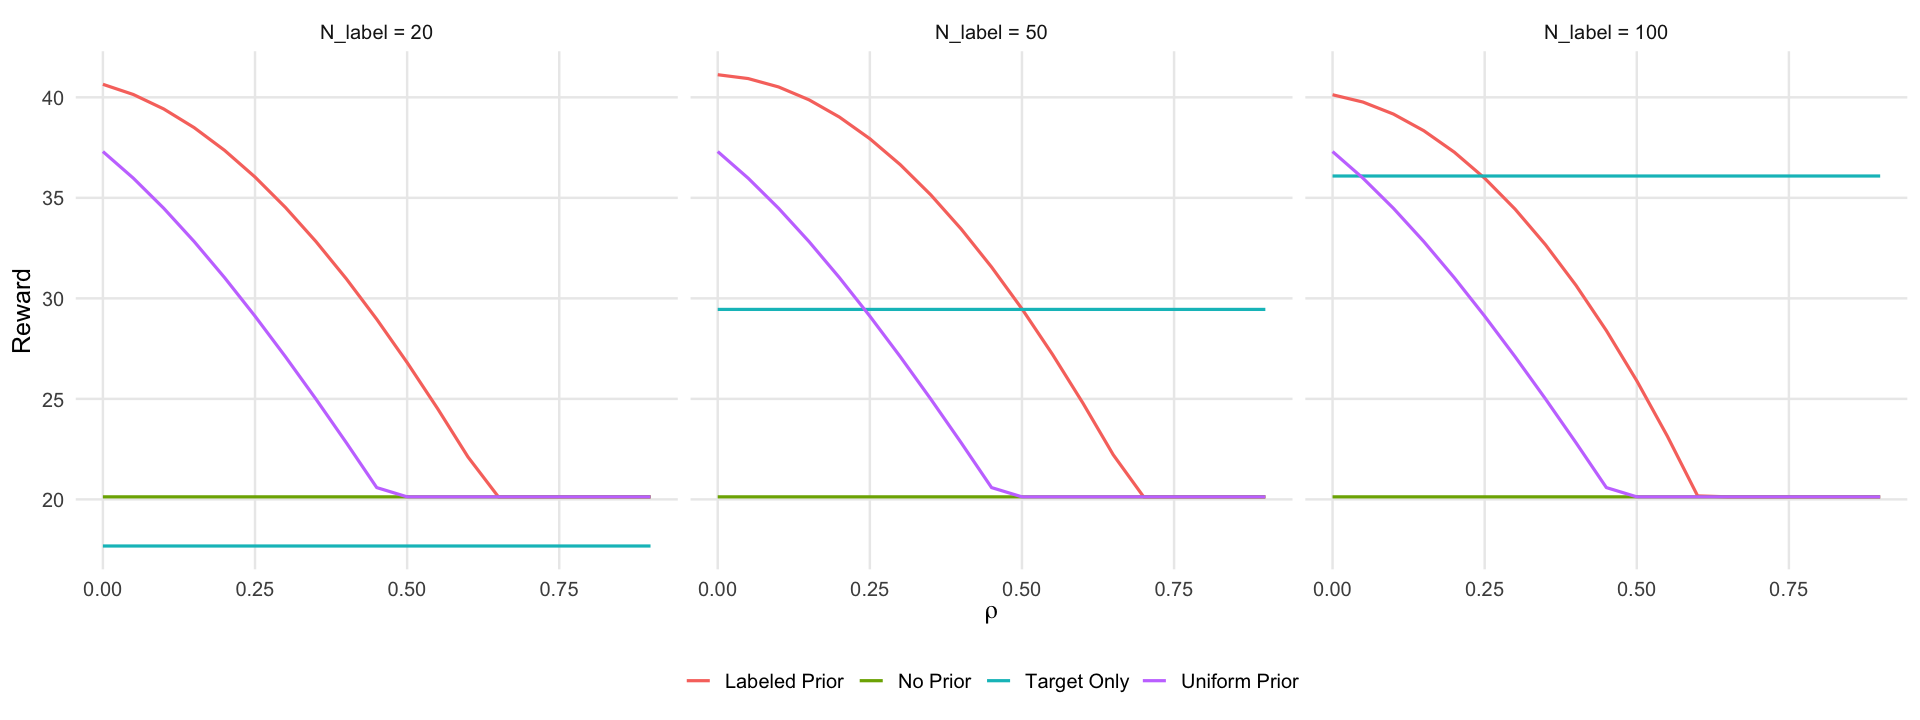

In [ ]:

# ------------------------------------------------------------------
# Plot (facets over N_label; lines over rho; 4 methods)
# ------------------------------------------------------------------
df <- NULL
for (iN in seq_along(N_labels)) {
  tmp <- as.data.frame(reward_array[iN,,])
  colnames(tmp) <- c("No Prior","Uniform Prior","Labeled Prior","Target Only")
  tmp$rho <- rhos
  tmp$N_label <- N_labels[iN]
  df <- rbind(df, tmp)
}
df_long <- df |>
  tidyr::pivot_longer(cols = c("No Prior","Uniform Prior","Labeled Prior","Target Only"),
                      names_to = "method", values_to = "reward")

gg <- ggplot(df_long, aes(x = rho, y = reward, color = method)) +
  geom_line(linewidth = 0.9) +
  facet_wrap(~ N_label, nrow = 1, scales = "fixed",
             labeller = labeller(N_label = function(v) paste0("N_label = ", v))) +
  labs(x = expression(rho),
       y = "Reward",
       color = NULL) +
  theme_minimal(base_size = 15) +
  theme(legend.position = "bottom",
        panel.grid.minor = element_blank())

options(repr.plot.width = 16, repr.plot.height = 6)
print(gg)